In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor


In [ ]:
data = pd.read_csv('../datasets/cleaned.csv')
target_col = 'Overall'
y = data[target_col]
mask = y.notna()
data = data[mask].copy()
y = y[mask]
drop_cols = [
    'ID', 'Name', 'Joined', 'Contract Valid Until',
    'Wage', 'Value', 'Release Clause',
    target_col
]
X = data.drop(columns=[c for c in drop_cols if c in data.columns])

categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.columns.difference(categorical_cols)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop'
)

In [ ]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('xgb', xgb)
])

param_grid = {
    'xgb__n_estimators': [400, 800],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__max_depth': [4, 6],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
    'xgb__min_child_weight': [1, 5],
    'xgb__reg_lambda': [1.0, 5.0]
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

grid = GridSearchCV(
    model,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_cv_rmse = (-grid.best_score_) ** 0.5
print("Best XGB params:", best_params)
print("Best CV RMSE:", best_cv_rmse)

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
print("Train MSE:" ,train_mse)
print("Test MSE:" ,test_mse)
print(f"Test RMSE:  {np.sqrt(test_mse):.3f}")
print(f"Test R2:    {r2_score(y_test, y_pred_test)}")


Best XGB params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 6, 'xgb__min_child_weight': 1, 'xgb__n_estimators': 800, 'xgb__reg_lambda': 5.0, 'xgb__subsample': 0.8}
Best CV RMSE: 0.791
Train MSE:  0.172
Test MSE:   0.605
Test RMSE:  0.778
Test R2:    0.987


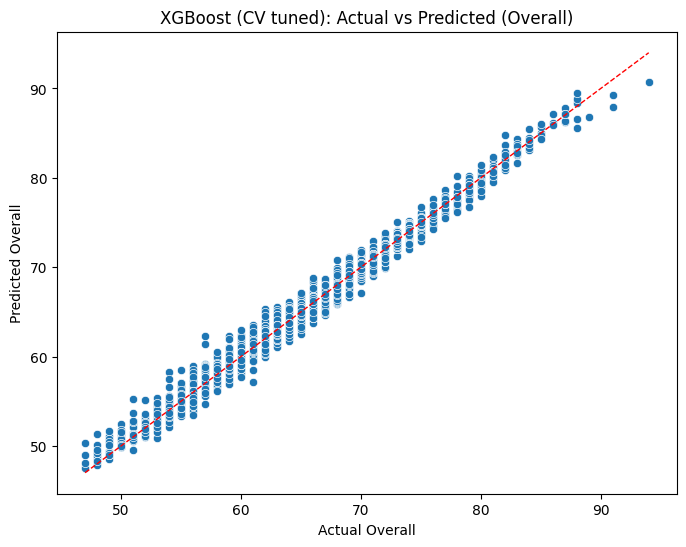

In [ ]:
sns.scatterplot(x=y_test, y=y_pred_test)
plt.xlabel("Actual Overall")
plt.ylabel("Predicted Overall")
plt.title("XGBoost (CV tuned): Actual vs Predicted (Overall)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.show()
